<a href="https://colab.research.google.com/github/juanpajedrez/learn_rag_Huggingface/blob/main/HuggingFace_Small_LLM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Small Language Model Fine-tuning with Hugging Face Transformers

### Why Fine-tune your own small Language Model

1. **Privacy** - Fine-tuning your own model means you can run it in your own hardware and not have to send any data to a company that isn't yours.
2. **Great Performance with a smaller footprint** - You'd often be surprised how far you can get with a fine-tuned smaller model for a specific task.
3. **Can run offline** - If you have a smaller custom model, you can deploy to edge hardware such as mobile devices and run it without an internet connection.
4. **Run it on batch mode** - A smaller model can often run with many samples at once (batch mode) and with inference engines such as vLLM, you can often use it on 100s to 1000s of samples per second. This allows for large-scale inference jobs.
5. **Cost Savings** - Once you've fine-tuned a small model to perform a particular task, you can run it over and over again without incurring API costs.

In [1]:
from google.colab import userdata
huggingface_token = userdata.get("HF_TOKEN")

In [2]:
!pip install huggingface_hub

In [3]:
# Note: If your google collab instance restarts and is erased, you will need to install the packages again
!pip install trl accelerate gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 45.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 555.1/555.1 kB 46.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.1/50.1 MB 51.6 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0


In [4]:
import huggingface_hub # requires !pip isntall huggingface_huv

# Login to Hugging Face Hub
huggingface_hub.login()

In [5]:
# Set TOKENIZERS_PARALLELISM = "false" to avoid warnings
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# Base imports
import transformers
import trl # trl = Transformers Reinforcement Learning -> https://github.com/huggingface/trl
import datasets
import accelerate

import gradio as gr

In [6]:
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"[INFO] Using device; {DEVICE}")

[INFO] Using device; cuda


In [7]:
!nvidia-smi

Tue Jul 14 00:10:15 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   50C    P8             14W /   72W |       3MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [8]:
# Check the amount of GPU memory available (we need at least ~16GB)
# CUDA = NVIDIA GPU backend
# MPS = macOS Metal Performance Shaders backend (Apple Silicon)
# Note: Training on macOS/MPS is significantly slower than on CUDA/NVIDIA GPUs.
# MPS is fine for learning, experimentation and inference, but expect longer training times.
import torch

DEVICE = "cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {DEVICE}")

if DEVICE == "cuda":
    device = torch.cuda.current_device()
    gpu_name = torch.cuda.get_device_name(device)

    total_memory = torch.cuda.get_device_properties(device).total_memory
    allocated_memory = torch.cuda.memory_allocated(device)
    reserved_memory = torch.cuda.memory_reserved(device)
    free_memory = total_memory - reserved_memory

    print(f"Backend: CUDA")
    print(f"GPU: {gpu_name}")
    print(f"Total Memory:     {total_memory / 1e6:.2f} MB | {total_memory / 1e9:.2f} GB")
    print(f"Allocated Memory: {allocated_memory / 1e6:.2f} MB | {allocated_memory / 1e9:.2f} GB")
    print(f"Reserved Memory:  {reserved_memory / 1e6:.2f} MB | {reserved_memory / 1e9:.2f} GB")
    print(f"Free Memory:      {free_memory / 1e6:.2f} MB | {free_memory / 1e9:.2f} GB")

elif DEVICE == "mps":
    # Note: MPS doesn't expose detailed memory stats like CUDA.
    # Apple Silicon uses unified memory (shared between CPU and GPU).
    # You can check total system memory as a proxy.
    import subprocess
    total_memory = int(subprocess.check_output(["sysctl", "-n", "hw.memsize"]).strip())

    print(f"Backend: MPS")
    print(f"Device: Apple Silicon (Metal Performance Shaders)")
    print(f"Total System Memory (unified): {total_memory / 1e6:.2f} MB | {total_memory / 1e9:.2f} GB")

    # Verify MPS works with a quick tensor test
    x = torch.tensor([1.0, 2.0]).to("mps")
    print(f"MPS tensor test: {x.device}")

else:
    print("No GPU available (no CUDA or MPS backend found)")

Using device: cuda
Backend: CUDA
GPU: NVIDIA L4
Total Memory:     23659.15 MB | 23.66 GB
Allocated Memory: 0.00 MB | 0.00 GB
Reserved Memory:  0.00 MB | 0.00 GB
Free Memory:      23659.15 MB | 23.66 GB


## Setup base model

We are going to use the base model: https://huggingface.co/google/gemma-3-270m

In [9]:
from transformers import AutoTokenizer, AutoModelForCausalLM

MODEL_NAME = "google/gemma-3-270m-it"

model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    dtype = "auto", # e.g: torch.float16, torch.bfloat16
    device_map = "auto",
    attn_implementation = "eager" # different version such as flah attention in  order for faster attention calculation in hardware
)

config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/536M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

In [10]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

print(f"[INFO] Model on device: {model.device}")
print(f"[INFO] Model using dtype: {model.dtype}")

tokenizer_config.json:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/662 [00:00<?, ?B/s]

chat_template.jinja:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

[INFO] Model on device: cuda:0
[INFO] Model using dtype: torch.bfloat16


In [11]:
tokenizer("Hello my name is Juan")

{'input_ids': [2, 9259, 1041, 1463, 563, 22424], 'attention_mask': [1, 1, 1, 1, 1, 1]}

In [12]:
tokenizer.all_special_tokens

['<bos>',
 '<eos>',
 '<unk>',
 '<pad>',
 '<mask>',
 '<start_of_image>',
 '<end_of_image>',
 '<image_soft_token>']

In [13]:
tokenizer.convert_ids_to_tokens([2, 9259, 1041, 1463, 563, 22424])

['<bos>', 'Hello', '▁my', '▁name', '▁is', '▁Juan']

In [14]:
import torch

# Add a batch dimension and also send it to target device
input_string = "Hello My name is Daniel!"
print(input_string)
token_tensor = torch.tensor(tokenizer(input_string)["input_ids"]).unsqueeze(0).to(DEVICE)

outputs = model(token_tensor)
outputs

Hello My name is Daniel!


CausalLMOutputWithPast(loss=None, logits=tensor([[[ -8.1875,  -0.2178,  -1.5391,  ...,  -9.0000,  -9.0625,  -9.0000],
         [-20.3750,  -6.9375,  -6.8125,  ..., -20.3750, -20.3750, -20.3750],
         [-17.1250,  -1.4062,  -2.3125,  ..., -16.6250, -16.5000, -16.5000],
         ...,
         [-11.5000,   2.2188,  -2.5469,  ...,  -9.8125,  -9.8125,  -9.8125],
         [-17.8750,   3.1094,  -7.7188,  ..., -16.2500, -16.2500, -16.2500],
         [-15.6250,   2.3906,  -5.8125,  ..., -14.3750, -14.3750, -14.3125]]],
       device='cuda:0', dtype=torch.bfloat16, grad_fn=<UnsafeViewBackward0>), past_key_values=DynamicCache(layers=[DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicLayer, DynamicSlidingWindowLayer, DynamicSlidingWindowLayer, DynamicSliding

In [15]:
logits = outputs.logits
print(f"{logits.shape} -> [batch_size, sequence_length, vocab_size] our model can handle vocab_size -> 262144 for Gemma 3 -> 270M")

torch.Size([1, 7, 262144]) -> [batch_size, sequence_length, vocab_size] our model can handle vocab_size -> 262144 for Gemma 3 -> 270M


### Tkens in, tokens out.

Our model has taken tokens in and assigned a value to each potential token in its output space (e.g. all of the unique tokens in its vocab).

In [16]:
# Get the predicted ids from the model outputs (logits)
predicted_ids = outputs.logits.argmax(dim = -1) # outputs shape: [1, seq_len]
print(f"[INFO] Predicted ids: {predicted_ids}")

[INFO] Predicted ids: tensor([[  1106, 236888,  28903,    563,    870, 236764,    564]],
       device='cuda:0')


In [17]:
# Decode them back to text
predicted_tokens = tokenizer.convert_ids_to_tokens(predicted_ids[0])
predicted_text = tokenizer.decode(predicted_ids[0])

print(f"[INFO] Predicted tokens: {predicted_tokens}")
print(f"[INFO] Predicted text: {predicted_text}")

[INFO] Predicted tokens: ['import', '!', '▁Friends', '▁is', '▁[', ',', '▁I']
[INFO] Predicted text: import! Friends is [, I


What might be going on here?

It turns that our model is trained with a particular token input format.

So when we directly pass strings such as "Hello my name is Daniel!", our model returns strange outputs...

We need to format our input string in a special way so our model returns better outputs.
  - **Note**: If your model has been trained in a certain way, for example, with a `chat_template` or certain input processor, it's important to make sure that we use the same method it was trained on when we use it, otherwise, we'll likely get poor results.

### Counting the number of parameters in our model

Number of parameters = Generally shows a model's capacity to learn. For example, larger parameter space = more ability to hold knowledge/information.

Our teacher model (the model that labelled all of our dataset is `gpt-oss-120b`).

Four our dataset/fine-tuning task, our goal is to take our labelling dataset and fine-tune Gemma 3 270M to predocue the labels from the larger model.

This practice is often referred to as **Distillation** - the practice of taking the outputs of a larger, more powerful model and using them to upskill or enhance the performance of a smaller model.

* Dataset = labelled captions with `gpt-oss-120b`
* Our goal = train Gemma 3 270M to repeat the task.

So in practice: You can create a dataset with the same workflow.

In [18]:
def get_model_num_params(model):
  """
  Return the number of trainable, non-trainable and total parameters of a PyTorch Model.
  """
  trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)  #.requires_grad == True => model parameter will be updated during training
  non_trainable_params = sum(p.numel() for p in model.parameters() if not p.requires_grad) #.requires_grad == False => model parameter will not be updated during training
  total_params = trainable_params + non_trainable_params
  return {"trainable_params": trainable_params,
          "non_trainable_params": non_trainable_params,
          "total_params": total_params}

# Get model params
model_params_counts = get_model_num_params(model)
print(f"[INFO] Model has {model_params_counts['total_params']:,} total parameters.")
print(f"[INFO] Model has {model_params_counts['trainable_params']:,} trainable parameters.")

[INFO] Model has 268,098,176 total parameters.
[INFO] Model has 268,098,176 trainable parameters.


In [19]:
gpt_oss_120b_parameters_count = 120_000_000_000
gemma_3_270m_parameter_count = model_params_counts["total_params"]

parameter_ratio = gpt_oss_120b_parameters_count / gemma_3_270m_parameter_count

print(f"[INFO] Gemma 3 270M is {parameter_ratio:.2f}x smaller than gpt-oss-120b (60Gb)")

[INFO] Gemma 3 270M is 447.60x smaller than gpt-oss-120b (60Gb)


### Getting a dataset

A custom dataset helps us fine-tune our target base model to do what we'd like it to do.

Think of a dataset: As a guide for your custom model

Resources:

* How to create a Hugging Face Datset: https://huggingface.co/docs/datasets/create_dataset

* Food Extract 1k dataset: https://huggingface.co/datasets/mrdbourke/FoodExtract-1k

When experimenting with a new model or problem space, best to start with a relatively small dataset and experiment to make sure things work ok before scaling right up.

In [20]:
from datasets import load_dataset
import datasets

DATASET_ID = "mrdbourke/FoodExtract-1k"
dataset = load_dataset(DATASET_ID)

# When you upload a dataset to Hugging Face, the default split is train
print(f"[INFO] Number of samples in the dataset: {len(dataset["train"])}")

README.md:   0%|          | 0.00/10.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/616k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/1420 [00:00<?, ? examples/s]

[INFO] Number of samples in the dataset: 1420


In [21]:
dataset

DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view'],
        num_rows: 1420
    })
})

Note: One of the first things to do with a new data problem, is to inspect the data samples randomly to build an idea of what's inside.

In [22]:
import ast
import random

def get_random_idx(dataset):
  """
  Return a random integer index based on the number of samples in the dataset.
  """
  random_idx = random.randint(0, len(dataset) - 1)
  return random_idx

random_idx = get_random_idx(dataset["train"])
random_sample = dataset["train"][random_idx]

print(f"[INFO] Random index: {random_idx}")
example_input = random_sample["sequence"]
example_output = random_sample["gpt-oss-120b-label"]
example_output_condensed = random_sample["gpt-oss-120b-label-condensed"]

print(f"[INFO] Input: {example_input}\n")
print(f"[INFO] Example output (JSON): {example_output}")
print(f"[INFO] Example output (condensed): {example_output_condensed}")

[INFO] Random index: 674
[INFO] Input: The image depicts an old newspaper article with a prominent heading at the top. The heading, enclosed in a box, reads "The Inquiring Reporter." The text is bold, black, and underlined, with each word capitalized: "The Inquiring Reporter." Below the heading, in slightly smaller and less bold text, it states, "Every day he asks five persons picked at random a question."

Another box further down the article reads, "The Tribune will pay $5 for each question accepted for The Inquiring Reporter to ask. Send name and address with your question to The Inquiring Reporter, Chicago Tribune."

For today's question, Anna H. Short, of 5124 Wilson Avenue, has been awarded $5. The question posed is: "What do you think a man should do if a woman approached him on the street saying she would scream unless he handed over her money?"

The location where the question was asked is specified as "South Street at Jackson Boulevard."

The article then lists the answers, s

In [23]:
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertisement',
 'fp': 'food_packaging'}


### Format dataset into LLM input/output style

We know LLMs (or SLMs) are general in the fact that they process sequences.

And sequences of tokens can represent almost anything.

Howeverm there's often a format to guide these in the right way.

If you want to see a collection of datasets formats for fine-tuning with TRL, see here: https://huggingface.co/docs/trl/en/dataset_formats

In [24]:
random_sample

{'sequence': 'The image depicts an old newspaper article with a prominent heading at the top. The heading, enclosed in a box, reads "The Inquiring Reporter." The text is bold, black, and underlined, with each word capitalized: "The Inquiring Reporter." Below the heading, in slightly smaller and less bold text, it states, "Every day he asks five persons picked at random a question."\n\nAnother box further down the article reads, "The Tribune will pay $5 for each question accepted for The Inquiring Reporter to ask. Send name and address with your question to The Inquiring Reporter, Chicago Tribune."\n\nFor today\'s question, Anna H. Short, of 5124 Wilson Avenue, has been awarded $5. The question posed is: "What do you think a man should do if a woman approached him on the street saying she would scream unless he handed over her money?"\n\nThe location where the question was asked is specified as "South Street at Jackson Boulevard."\n\nThe article then lists the answers, starting with Ms.

### Metadata
The metadata is also added in order to udneerstand where the data comes from, and possibly in the future how to expand the dataset.

In [25]:
def sample_to_conversation(sample):
  """
  Helper function to convert an input sample to prompt-completion style.
  """
  return {
      "prompt": [
          {"role" : "user",
          "content": sample["sequence"]} # Load the sequence from dataset
      ],
      "completion": [
          {"role": "assistant",
          "content": sample["gpt-oss-120b-label-condensed"]} # Load the label from dataset
      ]
  }

In [26]:
sample_to_conversation(random_sample)

{'prompt': [{'role': 'user',
   'content': 'The image depicts an old newspaper article with a prominent heading at the top. The heading, enclosed in a box, reads "The Inquiring Reporter." The text is bold, black, and underlined, with each word capitalized: "The Inquiring Reporter." Below the heading, in slightly smaller and less bold text, it states, "Every day he asks five persons picked at random a question."\n\nAnother box further down the article reads, "The Tribune will pay $5 for each question accepted for The Inquiring Reporter to ask. Send name and address with your question to The Inquiring Reporter, Chicago Tribune."\n\nFor today\'s question, Anna H. Short, of 5124 Wilson Avenue, has been awarded $5. The question posed is: "What do you think a man should do if a woman approached him on the street saying she would scream unless he handed over her money?"\n\nThe location where the question was asked is specified as "South Street at Jackson Boulevard."\n\nThe article then lists 

What if we wanted to apply this function to our whole dataset?

Well good news is... we can do so with `dataset.map()`

In [27]:
# Map our sample_to_conversation function to our dataset
dataset = dataset.map(function = sample_to_conversation)
dataset["train"][42]

Map:   0%|          | 0/1420 [00:00<?, ? examples/s]

{'sequence': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky',
 'image_url': 'https://portforward.com/games/walkthroughs/The-Legend-of-Zelda-The-Wind-Waker/The-Legend-of-Zelda-The-Wind-Waker-large-430.jpg',
 'class_label': 'not_food',
 'source': 'qwen2vl_open_dataset',
 'char_len': 156.0,
 'word_count': 28.0,
 'syn_or_real': 'real',
 'uuid': 'bbac79ce-df1f-48b8-891c-752809be11c7',
 'gpt-oss-120b-label': "{'is_food_or_drink': 'false', 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'role': 'user',
   'content': 'another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sk

### Creating a train/test split

We want to spluit our data into train/test sets (optional: 3rd set can be validation for hyperparameter fine-tuning).

* Train set = model will train on here and learn patterns to extract foods/drinks from text.
* Test set = we will evaluate the learned parameters/patterns from the train set on this split (the model will never have seen this in practice).

Kind of like at university, you learn the course material (training set) and then you take the final test, without looking the final exam questions (test set).

- `dataset.train_test_split()`: https://huggingface.co/docs/datasets/v4.8.4/en/package_reference/main_classes#datasets.Dataset.train_test_split

In [28]:
# Create a train/test split
dataset = dataset["train"].train_test_split(test_size = 0.2, # 20% of dataset to test
                                            shuffle = False,
                                            seed = 42) # Set the seed so we get the same split each time

In [29]:
dataset

DatasetDict({
    train: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 1136
    })
    test: Dataset({
        features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
        num_rows: 284
    })
})

In [30]:
dataset["train"]

Dataset({
    features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
    num_rows: 1136
})

In [31]:
dataset["test"]

Dataset({
    features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
    num_rows: 284
})

### Try our model with a pipeline

Pipeline = easieast way to get on hands a trained model to use models for inference.

See pipeline docs - https://huggingface.co/docs/transformers/main_classes/pipelines

In [32]:
def create_easy_sample(input):
  template = {"role": "user", "content": input}
  return template

create_easy_sample(input = "Hello my name is Juan")

{'role': 'user', 'content': 'Hello my name is Juan'}

In [33]:
from transformers import pipeline

# Load the model and use it as a pipeline
print(f"[INFO] Creating pipeline with model: {MODEL_NAME}")
pipe = pipeline(
    task = "text-generation",
    model = MODEL_NAME)

[INFO] Creating pipeline with model: google/gemma-3-270m-it


Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

In [34]:
input_text = "Pleasw write a poem about a Machine Learning engineer named Juan."
print(f"[INFO] This is the raw text input: \n {input_text} \n")

# Prepare the sample and tokenize
easy_sample = create_easy_sample(input = input_text)
print(f"[INFO] This is a formatted input text: \n {easy_sample} \n.")

# Turn it into an input prompt
input_prompt = pipe.tokenizer.apply_chat_template([easy_sample],
                                                  tokenize = False,
                                                  add_generation_prompt = True)

print(f"[INFO] This is the input prompt: \n {input_prompt} \n")


# Pass the prepared input prompt through the pipeline
default_outputs = pipe(input_prompt,
                       max_new_tokens = 512)

print(f"[INFO] This is the default output from {MODEL_NAME}: \n")

print(f"[INFO] This is the extracted model text: \n")
print(default_outputs[0]["generated_text"])

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] This is the raw text input: 
 Pleasw write a poem about a Machine Learning engineer named Juan. 

[INFO] This is a formatted input text: 
 {'role': 'user', 'content': 'Pleasw write a poem about a Machine Learning engineer named Juan.'} 
.
[INFO] This is the input prompt: 
 <bos><start_of_turn>user
Pleasw write a poem about a Machine Learning engineer named Juan.<end_of_turn>
<start_of_turn>model
 



[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GemmaTokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


[INFO] This is the default output from google/gemma-3-270m-it: 

[INFO] This is the extracted model text: 

<bos><start_of_turn>user
Pleasw write a poem about a Machine Learning engineer named Juan.<end_of_turn>
<start_of_turn>model
Juan, a coder bright,
With circuits humming in the night,
He crafts algorithms keen,
A mind of logic, a vibrant scene.

He learns with data's deep core,
A tapestry of points he's found.
From data streams to patterns bright,
He paints a future, pure delight.

He's a weaver, a master craftsman,
With every line, a new piece he's made.
A symphony of logic so bold,
A story told, in stories told.

He's trained on every kind of code,
A digital soul, a hopeful road.
He sees the world in patterns clear,
And shapes it with logic so near.

He's the architect of what's to be,
A future built with calculated glee.
A machine learning engineer's dream,
A digital artist, a vibrant gleam.

So let the algorithms run free,
And see the world, for all to see.
Juan, the coder, wi

In [35]:
# tokenizer.apply_chat_template?

In [36]:
print(tokenizer.chat_template)

{{ bos_token }}
{%- if messages[0]['role'] == 'system' -%}
    {%- if messages[0]['content'] is string -%}
        {%- set first_user_prefix = messages[0]['content'] + '

' -%}
    {%- else -%}
        {%- set first_user_prefix = messages[0]['content'][0]['text'] + '

' -%}
    {%- endif -%}
    {%- set loop_messages = messages[1:] -%}
{%- else -%}
    {%- set first_user_prefix = "" -%}
    {%- set loop_messages = messages -%}
{%- endif -%}
{%- for message in loop_messages -%}
    {%- if (message['role'] == 'user') != (loop.index0 % 2 == 0) -%}
        {{ raise_exception("Conversation roles must alternate user/assistant/user/assistant/...") }}
    {%- endif -%}
    {%- if (message['role'] == 'assistant') -%}
        {%- set role = "model" -%}
    {%- else -%}
        {%- set role = message['role'] -%}
    {%- endif -%}
    {{ '<start_of_turn>' + role + '
' + (first_user_prefix if loop.first else "") }}
    {%- if message['content'] is string -%}
        {{ message['content'] | trim }}


### Attempt 0: Try the model on one of our sequences:

In [37]:
# Get a a random sample
random_idx = get_random_idx(dataset["train"])
random_train_sample = dataset["train"][random_idx]
raw_text_input = random_train_sample["sequence"]
print(f"[INFO] This is our raw text input: \n{raw_text_input}\n")

# Apply the chat template
input_prompt = pipe.tokenizer.apply_chat_template(conversation=random_train_sample["prompt"],
                                                  tokenize = False,
                                                  add_generation_prompt = True)

# Let's run the default model on the input
default_outputs_on_custom_data = pipe(text_inputs = input_prompt, max_new_tokens = 256)

print(f"[INFO] This is the input prompt: \n {input_prompt}")

# View the model output
base_model_generated_text_on_custom_inputs = default_outputs_on_custom_data[0]["generated_text"][len(input_prompt):]
print(f"[INFO] Text generated by the model: {base_model_generated_text_on_custom_inputs}")

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] This is our raw text input: 
person an odyssey of growth hotel franchise, channel, novelty lighting, relationship building, digital tv, business planning, jordans, surfing, america

[INFO] This is the input prompt: 
 <bos><start_of_turn>user
person an odyssey of growth hotel franchise, channel, novelty lighting, relationship building, digital tv, business planning, jordans, surfing, america<end_of_turn>
<start_of_turn>model

[INFO] Text generated by the model: Okay, I've analyzed the information provided. It seems like you're looking for a franchise that focuses on a specific theme, like the "Odyssey of Growth" or the "Journey of Opportunity". Based on the information, here are a few potential franchise concepts that align with these themes:

*   **The Odyssey of Growth:** This franchise focuses on the journey of a person's personal and professional growth through various stages. It might emphasize building a strong foundation, developing skills, and achieving goals.
*   **The J

### Attempt 1: Let's try to prompt the model

In practice, smaller models out of the box, generally don't have the prompt-ability as larger models.

In [38]:
random_train_sample

{'sequence': 'person an odyssey of growth hotel franchise, channel, novelty lighting, relationship building, digital tv, business planning, jordans, surfing, america',
 'image_url': 'https://i.pinimg.com/originals/6c/b4/f8/6cb4f86ce9898e6cf49a5975c92a765b.jpg',
 'class_label': 'not_food',
 'source': 'qwen2vl_open_dataset',
 'char_len': 151.0,
 'word_count': 19.0,
 'syn_or_real': 'real',
 'uuid': '9c855e60-b19d-48f6-a62e-cb840d3f8633',
 'gpt-oss-120b-label': "{'is_food_or_drink': False, 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'role': 'user',
   'content': 'person an odyssey of growth hotel franchise, channel, novelty lighting, relationship building, digital tv, business planning, jordans, surfing, america'}],
 'completion': [{'role': 'assistant',
   'content': 'foo

In [39]:
prompt_instruction = """Given the following target input text from an image caption, please extract the food and drink items to a list.
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: <targ_input_text>"""

def update_input_message_content(input):
  """
  Helper function to format our prompt with target input text from a given message sample
  """
  original_content = input["prompt"][0]["content"]
  new_content = prompt_instruction.replace("<targ_input_text>", original_content)
  new_input = [{"content": new_content,
                "role": "user"}]
  return new_input

In [40]:
print(f"[INFO] Original Content: \n{random_train_sample['prompt'][0]['content']}\n")
print(f"[INFO] New Content with instructions in prompt: \n{update_input_message_content(random_train_sample)[0]['content']}\n")

[INFO] Original Content: 
person an odyssey of growth hotel franchise, channel, novelty lighting, relationship building, digital tv, business planning, jordans, surfing, america

[INFO] New Content with instructions in prompt: 
Given the following target input text from an image caption, please extract the food and drink items to a list.
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: person an odyssey of growth hotel franchise, channel, novelty lighting, relationship bu

### Trying our formatted prompt with the model

In [41]:
# Apply the chat template (jinja file in huggingface)
updated_input_prompt = update_input_message_content(input = random_train_sample)

input_prompt = pipe.tokenizer.apply_chat_template(conversation = updated_input_prompt,
                                                  tokenize = False,
                                                  add_generation_prompt = True)

# Let's run the default model on our fomratted input with instructions prompt
default_outputs = pipe(text_inputs = input_prompt,
                       max_new_tokens = 256)

# View and compare inputs and outputs
print(f"[INFO] Input text: \n{input_prompt}\n")
print(f"[INFO] Output: \n{default_outputs[0]['generated_text'][len(input_prompt):]}\n")

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] Input text: 
<bos><start_of_turn>user
Given the following target input text from an image caption, please extract the food and drink items to a list.
If there are no food or drink items, return an empty list.

Return in the following format:
food_items: [food_item_1, food_item_2, food_item_3]
drink_items: [drink_item_4, drink_item_5]

For example:
Input text: Hello my name is Daniel.
Output:
food_items: []
drink_items: []

Example 2:
Input text: A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.
Output:
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tomatoes']
drink_items: ['cup of tea']

Return only the formatted output and nothing else.

Target input text: person an odyssey of growth hotel franchise, channel, novelty lighting, relationship building, digital tv, business planning, jordans, surfing, america<end_of_turn>
<start_of_turn>model


[INFO] Output: 
food_items: ['rice cakes', 'salmon', 'cottage cheese', 'cherry tom

In [42]:
# This is our input
print(f"[INFO] Raw text input:")
print(random_train_sample["prompt"][0]["content"])

# This is our ideal output
print()
print(f"[INFO] Ideal output:")
print(random_train_sample["completion"][0]["content"])

[INFO] Raw text input:
person an odyssey of growth hotel franchise, channel, novelty lighting, relationship building, digital tv, business planning, jordans, surfing, america

[INFO] Ideal output:
food_or_drink: 0
tags: 
foods: 
drinks:


Workflow we've done

* Try our base model with straight text input - doesnt work for our task.
* Try the base model with an instruction prompt - works well for lage models like Gemini, but not as reliable for Gemma 3 270M (our SLM).
* Nex: Let's fine-tune Gemma 3 270M for our specific task and see if it improves it.

### Fine-tuning our base model for our specific task

We need 3 things for fine-tuning
1. A dataset (what are our model's ideal inputs and outputs), these can be as simple as text pairs. - We've got this!
2. `SFTConfig` - Supervised FIne-Tuning Config - These are the settings/hyperparameters for the model training. - Link: https://huggingface.co/docs/trl/v1.7.1/en/sft_trainer#trl.SFTConfig -We've got this
3. `SFTTrainer` - Takes in the settings, the target model, the target dataset and puts them altogether training the model on the train dataset using the settings - https://huggingface.co/docs/trl/v1.7.1/en/sft_trainer#trl.SFTTrainer

In [43]:
from trl import SFTConfig

torch_dtype = model.dtype
CHECKPOINT_DIRNAME = "./checkpoint_models"
BASE_LEARNING_RATE = 5e-5 # learning_rate = value that multiplies how big of a step the optimizer takes when updating internal weights of the model.
BATCH_SIZE = 16 # Change this depending on the VRAM you have available
NUM_TRAIN_EPOCHS = 3

print(f"[INFO] Using dtype: {torch_dtype}")
print(f"[INFO] Saving checkpoints to: {CHECKPOINT_DIRNAME}")
print(f"[INFO] Using base learning rate: {BASE_LEARNING_RATE}")
print(f"[INFO] Using batch size: {BATCH_SIZE}")
print(f"[INFO] Training for epochs: {NUM_TRAIN_EPOCHS}")

print()

# Setup our SFTConfig
sft_config = SFTConfig(
    output_dir = CHECKPOINT_DIRNAME,
    max_length = 512, # captions/text that go into our model that are longer than this will get automatically shortened
    packing = False,
    num_train_epochs = NUM_TRAIN_EPOCHS,
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size = BATCH_SIZE,
    completion_only_loss = True, # Only evaluate its outputs based on the sample["completion"]["content"] tokens: Link: https://huggingface.co/docs/trl/v1.7.1/en/sft_trainer#trl.SFTTrainer
    gradient_checkpointing = False, # Use this if you have a really small GPU and want memory efficiency, at the cost of time.
    optim = "adamw_torch_fused", # Uses this optimizer = https://docs.pytorch.org/docs/2.12/generated/torch.optim.AdamW.html
    logging_steps = 1, # How often to log to the console
    save_strategy = "epoch", # Save every 1x epoch
    eval_strategy = "epoch",
    learning_rate = BASE_LEARNING_RATE,
    fp16 = (torch_dtype == torch.float16),
    bf16 = (torch_dtype == torch.bfloat16),
    load_best_model_at_end = True,
    metric_for_best_model = "mean_token_accuracy", # acc metrics = higher is better, loss = lower is better
    greater_is_better = True, # adjust this based wheter your best metrics is acc-based/loss-based
    lr_scheduler_type = "constant",
    push_to_hub = False, # Optionally upload model to HF Hub automatically after training
    report_to = "none" # experiment tracking, report metrics to a tracker. e.g: trackio or weightsbiases https://huggingface.co/blog/trackio
)

[INFO] Using dtype: torch.bfloat16
[INFO] Saving checkpoints to: ./checkpoint_models
[INFO] Using base learning rate: 5e-05
[INFO] Using batch size: 16
[INFO] Training for epochs: 3



In [44]:
random_train_sample

{'sequence': 'person an odyssey of growth hotel franchise, channel, novelty lighting, relationship building, digital tv, business planning, jordans, surfing, america',
 'image_url': 'https://i.pinimg.com/originals/6c/b4/f8/6cb4f86ce9898e6cf49a5975c92a765b.jpg',
 'class_label': 'not_food',
 'source': 'qwen2vl_open_dataset',
 'char_len': 151.0,
 'word_count': 19.0,
 'syn_or_real': 'real',
 'uuid': '9c855e60-b19d-48f6-a62e-cb840d3f8633',
 'gpt-oss-120b-label': "{'is_food_or_drink': False, 'tags': [], 'food_items': [], 'drink_items': []}",
 'gpt-oss-120b-label-condensed': 'food_or_drink: 0\ntags: \nfoods: \ndrinks:',
 'target_food_names_to_use': None,
 'caption_detail_level': None,
 'num_foods': None,
 'target_image_point_of_view': None,
 'prompt': [{'role': 'user',
   'content': 'person an odyssey of growth hotel franchise, channel, novelty lighting, relationship building, digital tv, business planning, jordans, surfing, america'}],
 'completion': [{'role': 'assistant',
   'content': 'foo

In [45]:
!nvidia-smi

Tue Jul 14 00:11:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA L4                      Off |   00000000:00:03.0 Off |                    0 |
| N/A   59C    P0             32W /   72W |    1318MiB /  23034MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Setting up `SFTTrainer`, the conductor of our model training

`SFTTrainer` will bring together our target model, our target dataset and our tagret settings and mix them together in a big pot!

Of course, it does more than that.

In [46]:
model

Gemma3ForCausalLM(
  (model): Gemma3TextModel(
    (embed_tokens): Gemma3TextScaledWordEmbedding(262144, 640, padding_idx=0)
    (layers): ModuleList(
      (0-17): 18 x Gemma3DecoderLayer(
        (self_attn): Gemma3Attention(
          (q_proj): Linear(in_features=640, out_features=1024, bias=False)
          (k_proj): Linear(in_features=640, out_features=256, bias=False)
          (v_proj): Linear(in_features=640, out_features=256, bias=False)
          (o_proj): Linear(in_features=1024, out_features=640, bias=False)
          (q_norm): Gemma3RMSNorm((256,), eps=1e-06)
          (k_norm): Gemma3RMSNorm((256,), eps=1e-06)
        )
        (mlp): Gemma3MLP(
          (gate_proj): Linear(in_features=640, out_features=2048, bias=False)
          (up_proj): Linear(in_features=640, out_features=2048, bias=False)
          (down_proj): Linear(in_features=2048, out_features=640, bias=False)
          (act_fn): GELUTanh()
        )
        (input_layernorm): Gemma3RMSNorm((640,), eps=1e-06)

In [47]:
dataset["train"]

Dataset({
    features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
    num_rows: 1136
})

In [48]:
dataset["test"]

Dataset({
    features: ['sequence', 'image_url', 'class_label', 'source', 'char_len', 'word_count', 'syn_or_real', 'uuid', 'gpt-oss-120b-label', 'gpt-oss-120b-label-condensed', 'target_food_names_to_use', 'caption_detail_level', 'num_foods', 'target_image_point_of_view', 'prompt', 'completion'],
    num_rows: 284
})

In [49]:
from trl import SFTTrainer # Supervised Fine-tuning trainer

# Create trainer Object
trainer = SFTTrainer(
    model = model,
    args = sft_config, # hyperparameters/settings for our model training
    train_dataset = dataset["train"],
    eval_dataset = dataset["test"],
    processing_class = tokenizer, # This is how to convert input prompts into gemma3 270M/it tokens
)

# Fine-tune our model and save the training artifacts/logs
training_output = trainer.train()

Tokenizing train dataset:   0%|          | 0/1136 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/1136 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/1136 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/284 [00:00<?, ? examples/s]

Building labels for eval dataset:   0%|          | 0/284 [00:00<?, ? examples/s]

...

Epoch,Training Loss,Validation Loss,Entropy,Num Tokens,Mean Token Accuracy
1,0.277785,0.084520,0.077348,170969.000000,0.979659
2,0.069512,0.078991,0.045349,341938.000000,0.982616
3,0.101607,0.087643,0.034599,512907.000000,0.981062


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


### Evaluating our fine-tuned model

In [50]:
eval_metrics = trainer.evaluate()

print(f"[INFO] Eval metrics:")
eval_metrics

Training Loss,Validation Loss,Epoch,Entropy,Num Tokens,Mean Token Accuracy
0.101607,0.078991,3,0.045349,512907.000000,0.982616


[INFO] Eval metrics:


{'eval_loss': 0.07899075746536255,
 'eval_entropy': 0.0453492627841317,
 'eval_num_tokens': 512907.0,
 'eval_mean_token_accuracy': 0.9826159146096971}

### Inspect our model loss curves

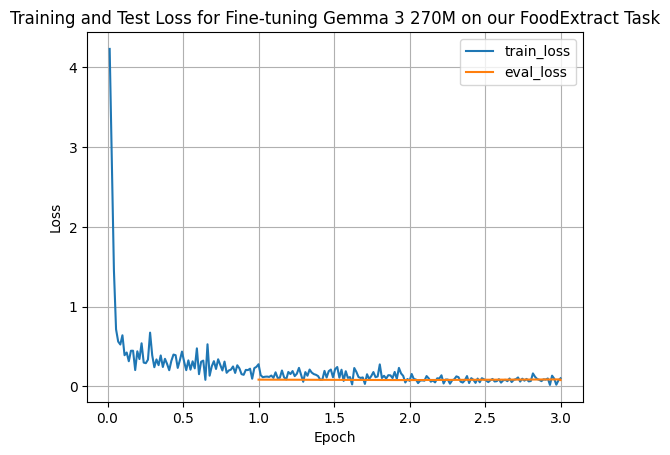

In [51]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history

# Extract tranining/validation loss
train_losses = [log["loss"] for log in log_history if "loss" in log]
epoch_train = [log["epoch"] for log in log_history if "loss" in log]

# Eval loss and stats
eval_losses = [log["eval_loss"] for log in log_history if "eval_loss" in log]
epoch_eval = [log["epoch"] for log in log_history if "eval_loss" in log]

# Plot the training loss curves
plt.plot(epoch_train, train_losses, label = "train_loss")
plt.plot(epoch_eval, eval_losses, label = "eval_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Test Loss for Fine-tuning Gemma 3 270M on our FoodExtract Task")
plt.legend()
plt.grid(True)
plt.show()

### Save the best model to file

Save the best model to file, in order to import it back for later inference.

In [52]:
!ls checkpoint_models/

checkpoint-142	checkpoint-213	checkpoint-71  README.md


In [53]:
# Save best model
trainer.save_model()

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

### Optional: Delete checkpoint to save on space

Maybe you want to keep your checkpoints, if so, all good please ignore the following cells.

If you want to cleanup your checkpoints and just save and share the best model, you can remove the folders with the following.

In [54]:
!rm -rf checkpoint_models/checkpoint-*/*
!rm -rf checkpoint_models/checkpoint-*

In [55]:
!ls checkpoint_models/

chat_template.jinja	model.safetensors      tokenizer.json
config.json		README.md	       training_args.bin
generation_config.json	tokenizer_config.json


# Next load in the best model, then evaluate in on actual samples (side by side comparison)

In [56]:
# Load the fine-tuned model with transformers
from transformers import AutoTokenizer, AutoModelForCausalLM

# Checkpoint dir
CHECKPOINT_DIR_NAME = "./checkpoint_models"

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path = CHECKPOINT_DIR_NAME)

# Load the model
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path = CHECKPOINT_DIR_NAME,
    dtype = "auto",
    device_map = "auto",
    attn_implementation = "eager")

Loading weights:   0%|          | 0/236 [00:00<?, ?it/s]

In [57]:
from transformers import pipeline

loaded_model_pipeline = pipeline("text-generation",
                                 model = loaded_model,
                                 tokenizer = tokenizer)
loaded_model_pipeline

TextGenerationPipeline: {'model': 'Gemma3ForCausalLM', 'dtype': 'bfloat16', 'device': 'cuda', 'input_modalities': ('image', 'text'), 'output_modalities': ('text',)}

In [58]:
loaded_model_pipeline("Hello My name is Juan!")

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': 'Hello My name is Juan! \nfood_or_drink: 0\ntags: \nfoods: \ndrinks:'}]

### Using our loaded model to make test predictions.

Making predictions is also referenced to as inference.

A good practice is to make random predictions on the test dataset and inspect them visually to see how they go. Metrics are on ething but you can't beat looking at actual data.

Similar exploring a new dataset, once you've trained a model, try it on ~100 random samples

In [59]:
import random

random_test_idx = random.randint(0, len(dataset["test"]) - 1)
random_test_sample = dataset["test"][random_test_idx]

# Apply the chat-template with jinja file
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation = random_test_sample["prompt"],
                                                                   tokenize = False,
                                                                   add_generation_prompt = True)

# Let's run the loaded model on our input
loaded_model_outputs = loaded_model_pipeline(text_inputs = input_prompt,
                                             max_new_tokens = 256)

# Print out test sample ground truth as well as the model's generated output
print()
print(f"[INFO] Test sample input prompt: \n{input_prompt}\n")
print(f"[INFO] Test sample ground truth: \n{random_test_sample['completion'][0]['content']}\n")
print(f"[INFO] Test sample model output: \n{loaded_model_outputs[0]['generated_text'][len(input_prompt):]}\n")
print(f"[INFO] Test label (ideal output): \n{random_test_sample["gpt-oss-120b-label-condensed"]}")

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



[INFO] Test sample input prompt: 
<bos><start_of_turn>user
The image shows a package of "Helpful Harvest" dried vegetables. The ingredients include a variety of vegetables such as zucchini, carrots, mushrooms, onions, capsicum, and celery. The product is made from 100% vegetables and includes wonky and overly abundant produce where possible. The package notes that the ingredients and percentages may differ due to seasonal availability.

The allergens listed are milk, eggs, soy, sesame seeds, hazelnuts, pistachios, cashews, and almonds. The nutrition information indicates that the package contains 4 servings, with each serving size being 10g. The average quantities per serving are as follows:
- Energy: 125 kJ
- Protein: 1.9 g
- Gluten: 0 g (marked as gluten-free)
- Fat, total: 0.3 g
- Saturated fat: 0 g
- Carbohydrate: 3.4 g
- Sugars: 3.4 g
- Fibre: 3.4 g
- Sodium: 2.1 g

The average quantities per 100g are:
- Energy: 1250 kJ
- Protein: 18.7 g
- Fat, total: 2.8 g
- Saturated fat: 0 g
-

### Notes on mistakes our model makes
- **Edge case 1:** fine-tuned model predicted "koi fish" as food, is this correct?
- **Edge case 2:** When getting from ingredients list, we are getting everything, yet we are also getting food descriptions like: Baked, Roasted, Sliced, Sweet.

### Making a helper function to predict on any given sample

Want:

* Simple funciton to predict on any text.
* Bonus: Measure the time it takes (latency)

In [60]:
import time

def pred_on_text(input_text:str,
                 max_new_tokens = 256):
  start_time = time.time()
  raw_output = loaded_model_pipeline(text_inputs = [{"role": "user",
                                                    "content": input_text}],
                                     max_new_tokens = max_new_tokens)
  end_time = time.time()
  total_time = round(end_time - start_time, 4)
  generated_text = raw_output[0]["generated_text"][1]["content"]
  return generated_text, raw_output, total_time

In [61]:
#example_input_text = "British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes"\
#example_input_text = "A drink of water, with a plate of food with fried eggs, yellow tracktor, beef patties, carrot, pickles, sesame seeds, aioli sauce, tomato sauce, snap peas, white rice, soy sauce, green shallots"
example_input_text = "A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea."
output_text, output_raw, output_total_time = pred_on_text(input_text=example_input_text)

print(f"[INFO] Input text:\n{example_input_text}\n")
print(f"[INFO] Model generated output text:\n{output_text}\n")
print(f"[INFO] Model full raw output:\n{output_raw}\n")
print(f"[INFO] Inference time:\n{output_total_time}\n")

[transformers] Both `max_new_tokens` (=256) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[INFO] Input text:
A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.

[INFO] Model generated output text:
food_or_drink: 1
tags: fi
foods: rice cakes, salmon, cottage cheese, cherry tomatoes
drinks: tea

[INFO] Model full raw output:
[{'generated_text': [{'role': 'user', 'content': 'A plate of rice cakes, salmon, cottage cheese and small cherry tomatoes with a cup of tea.'}, {'role': 'assistant', 'content': 'food_or_drink: 1\ntags: fi\nfoods: rice cakes, salmon, cottage cheese, cherry tomatoes\ndrinks: tea'}]}]

[INFO] Inference time:
1.1603



**Note:** We test inference time because this is important for your application. If you have a good but slow model, it might not be usable. You often want the ideal split between a fast and good modell.

## Uploading our fine-tuned model to Hugging Face Hub

Reasons for doing so:

* Easily store and lodad the model in the future.
* Share our model with our colleagues or with the general public.
* Version our model with communicative information and version numbers.

To upload to Hugging Face Hub, we need to use the library `huggingface_hub`

In [62]:
from huggingface_hub import HfApi, create_repo

api = HfApi()

# Setup my Hugging Face Username
HF_USERNAME = "juanpajedrez" # Change this to our own

# Create the repo (this is in the format {HF_USERNAME/{REPO_NAME}})
repo_id = f"{HF_USERNAME}/FoodExtract-gemma-3-270m-fine-tune-v1-VIDEO"

# Create the repo
create_repo(repo_id = repo_id,
            repo_type = "model",
            private = False,
            exist_ok = True)

RepoUrl('https://huggingface.co/juanpajedrez/FoodExtract-gemma-3-270m-fine-tune-v1-VIDEO', endpoint='https://huggingface.co', repo_type='model', repo_id='juanpajedrez/FoodExtract-gemma-3-270m-fine-tune-v1-VIDEO')

**Note:** "Repo" is short for repository (a place to store data + files + information).

### Create a README.md for our model

In model world, a README for a model is often referred to as a **model card**.

Inside a model card, we usually include things like:

* What the model does.
* How it was trained
* The data that was used.
* The results of the model.
* Examples of it being used in practice.
* License

More...

See more here: https://huggingface.co/docs/hub/model-cards

```
---
base_model: google/gemma-3-270m-it
library_name: transformers
model_name: checkpoint_models
tags:
- generated_from_trainer
- sft
- trl
license: gemma
---

```

In [63]:
# Next: Create a README.md to our repo to know what our model does.
model_readme = r"""---
base_model: google/gemma-3-270m-it
library_name: transformers
model_name: checkpoint_models
tags:
- generated_from_trainer
- sft
- trl
license: gemma
---

# FoodExtract-v1-VIDEO

This is a food and drink extraction language model built on [Gemma 3 270M](https://huggingface.co/google/gemma-3-270m-it).

Given raw text, it's designed to:

1. Classify the text into food or drink (e.g. "a photo of a dog" = not food or drink, "a photo of a pizza" = food or drink).
2. Tag the text with one or more tags (see tags_dict below).
3. Extract the edible food-related items as a list.
4. Extract the edible drink-related items as a list.

For example, the input text might be:

```
British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes
```

And the model will generate:

```
food_or_drink: 1
tags: fi, di
foods: British Breakfast, baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, toast, fried tomatoes
drinks: tea
```

This model can be used for filtering a large image caption (e.g. [DataComp-1B](https://huggingface.co/datasets/UCSC-VLAA/Recap-DataComp-1B)) text dataset for food and drink related items.

## Dataset

The model was trained on the [FoodExtract-1k](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k) dataset.

This dataset contains 1400 samples of raw text and JSON output pairs of structured food extractions provided by `gpt-oss-120b`.

For example, a raw image caption input might be:

```
another optional quest takes place on windfall island during the night time play the song of passing a number of times and each time, glance towards the sky
```

And the `gpt-oss-120b` generated output (JSON) would be:

```
{'is_food_or_drink': 'false', 'tags': [], 'food_items': [], 'drink_items': []}
```

This is condensed to:

```
food_or_drink: 0\ntags: \nfoods: \ndrinks:
```

### Tags dictionary mapping

These tags are designed for fast filtering.

For example, the model can assign a certain tag based on what's in the raw text and then we can filter for "ingredient list" items.

```
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertistment',
 'fp': 'food_packaging'}
```

## Helper functions

The model is trained to output a condensed version of the structured data.

We do this so the model can generate less tokens (e.g. it doesn't have to generate JSON outputs).

The following functions help to condense and uncondense raw text outputs/inputs into the desired structure.

```python
def condense_output(original_output):
    '''Helper function to condense a given FoodExtract string.

    Example input: {'is_food_or_drink': True, 'tags': ['fi'], 'food_items': ['cape gooseberries', 'mulberry', 'chilli powder', 'flathead lobster', 'hoisin sauce', 'duck leg', 'chestnuts', 'raw quail', 'duck breast', 'rogan josh curry sauce', 'brown rice', 'dango'], 'drink_items': []}

    Example output: food_or_drink: 1\ntags: fi\nfoods: cape gooseberries, mulberry, chilli powder, flathead lobster, hoisin sauce, duck leg, chestnuts, raw quail, duck breast, rogan josh curry sauce, brown rice, dango\ndrinks:'''

    condensed_output_string_base = '''food_or_drink: <is_food_or_drink>
    tags: <output_tags>
    foods: <food_items>
    drinks: <drink_items>'''

    is_food_or_drink = str(1) if str(original_output["is_food_or_drink"]).lower() == "true" else str(0)
    tags = ", ".join(original_output["tags"]) if len(original_output["tags"]) > 0 else ""
    foods = ", ".join(original_output["food_items"]) if len(original_output["food_items"]) > 0 else ""
    drinks = ", ".join(original_output["drink_items"]) if len(original_output["drink_items"]) > 0 else ""

    condensed_output_string_formatted = condensed_output_string_base.replace("<is_food_or_drink>", is_food_or_drink).replace("<output_tags>", tags).replace("<food_items>", foods).replace("<drink_items>", drinks)

    return condensed_output_string_formatted.strip()

def uncondense_output(condensed_output):
    '''Helper to go from condensed output to uncondensed output.

    Example input: food_or_drink: 1\ntags: fi\nfoods: cape gooseberries, mulberry, chilli powder, flathead lobster, hoisin sauce, duck leg, chestnuts, raw quail, duck breast, rogan josh curry sauce, brown rice, dango\ndrinks:

    Example output: {'is_food_or_drink': True, 'tags': ['fi'], 'food_items': ['cape gooseberries', 'mulberry', 'chilli powder', 'flathead lobster', 'hoisin sauce', 'duck leg', 'chestnuts', 'raw quail', 'duck breast', 'rogan josh curry sauce', 'brown rice', 'dango'], 'drink_items': []}
    '''

    condensed_list = condensed_output.split("\n")

    condensed_dict_base = {
        "is_food_or_drink": "",
        "tags": [],
        "food_items": [],
        "drink_items": []
    }

    # Set values to defaults
    food_or_drink_item = None
    tags_item = None
    foods_item = None
    drinks_item = None

    # Extract items from condensed_list
    for item in condensed_list:
        if "food_or_drink:" in item.strip():
            food_or_drink_item = item

        if "tags:" in item:
            tags_item = item

        if "foods:" in item:
            foods_item = item

        if "drinks:" in item:
            drinks_item = item

    if food_or_drink_item:
        is_food_or_drink_bool = True if food_or_drink_item.replace("food_or_drink: ", "").strip() == "1" else False
    else:
        is_food_or_drink_bool = None

    if tags_item:
        tags_list = [item.replace("tags: ", "").replace("tags:", "").strip() for item in tags_item.split(", ")]
        tags_list = [item for item in tags_list if item] # Filter for empty items
    else:
        tags_list = []

    if foods_item:
        foods_list = [item.replace("foods:", "").replace("foods: ", "").strip() for item in foods_item.split(", ")]
        foods_list = [item for item in foods_list if item] # Filter for empty items
    else:
        foods_list = []

    if drinks_item:
        drinks_list = [item.replace("drinks:", "").replace("drinks: ", "").strip() for item in drinks_item.split(", ")]
        drinks_list = [item for item in drinks_list if item] # Filter for empty items
    else:
        drinks_list = []

    condensed_dict_base["is_food_or_drink"] = is_food_or_drink_bool
    condensed_dict_base["tags"] = tags_list
    condensed_dict_base["food_items"] = foods_list
    condensed_dict_base["drink_items"] = drinks_list

    return condensed_dict_base
````

## Quick start

```python
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

MODEL_PATH = "mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1"

# Load the model into a pipeline
loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    dtype="auto",
    device_map="auto",
    attn_implementation="eager"
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
)

# Create model pipeline
loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

# Create a sample to predict on
input_text = "A plate with bacon, eggs and toast on it"
input_text_user = [{'content': input_text, 'role': 'user'}]

# Apply the chat template
input_prompt = loaded_model_pipeline.tokenizer.apply_chat_template(conversation=input_text_user,
                                                                    tokenize=False,
                                                                    add_generation_prompt=True)

# Let's run the default model on our input
default_outputs = loaded_model_pipeline(text_inputs=input_prompt,
                                        max_new_tokens=256)

# View the outputs
print(f"[INFO] Test sample input:\n{input_prompt}\n")
print(f"[INFO] Fine-tuned model output:\n{default_outputs[0]['generated_text'][len(input_prompt):]}\n")
```

You should see an output similar to:

```
[INFO] Test sample input:
<bos><start_of_turn>user
A plate with bacon, eggs and toast on it<end_of_turn>
<start_of_turn>model

[INFO] Fine-tuned model output:
food_or_drink: 1
tags: fi
foods: bacon, eggs, toast
drinks:
```

## Training procedure

This model was trained with SFT (Supervised Fine-Tuning) via Hugging Face's TRL library.

See the full training walkthrough at: https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial

## Citations

* Reference for structured data extraction was taken from the paper [*Essential-Web v1.0: 24T tokens of organized web data*](https://huggingface.co/papers/2506.14111) and the subsequent fine-tuned model [`EssentialAI/eai-distill-0.5b`](https://huggingface.co/EssentialAI/eai-distill-0.5b)."""

# Save README to file
with open(f"{CHECKPOINT_DIR_NAME}/README.md", "w") as f:
    f.write(model_readme)

### Uploading the contents of our checkpoint folder to the Hugging Face Hub

In [64]:
api.upload_folder?

In [65]:
# Upload the entire model folder containing our model files and README.md
print(f"[INFO] Uploading checkpoint directory: {CHECKPOINT_DIR_NAME} to Hugging Face repo: {repo_id}")
api.upload_folder(
    folder_path="./checkpoint_models/",
    repo_id=repo_id,
    repo_type="model"
)

[INFO] Uploading checkpoint directory: ./checkpoint_models to Hugging Face repo: juanpajedrez/FoodExtract-gemma-3-270m-fine-tune-v1-VIDEO


CommitInfo(commit_url='https://huggingface.co/juanpajedrez/FoodExtract-gemma-3-270m-fine-tune-v1-VIDEO/commit/508d8e2639867523e8f060d128eee3eaaae36a32', commit_message='Upload folder using huggingface_hub', commit_description='', oid='508d8e2639867523e8f060d128eee3eaaae36a32', pr_url=None, repo_url=RepoUrl('https://huggingface.co/juanpajedrez/FoodExtract-gemma-3-270m-fine-tune-v1-VIDEO', endpoint='https://huggingface.co', repo_type='model', repo_id='juanpajedrez/FoodExtract-gemma-3-270m-fine-tune-v1-VIDEO'), pr_revision=None, pr_num=None)

**Note** Hugging Face Storage uses XeT to upload all files

## Turning our model into a demo

To turn our model into a demo, so other people can use it themselves, we can use gradio:

See link there: https://gradio.app/

To make a gradio demo we need:
* Input (.eg data/raw text).
* Functio (e.g. our model to process the input).
* Output (e.g. What comes from our model)

```
Input -> Function (e.g. our fine-tuned model) -> Output
```

Once we have built our Gradio demo, we can deploy it to our huggignface spaces.

In [88]:
!mkdir demos/
!mkdir demos/FoodExtract

What files do we need?
* `README.md` explains whats our demo does.
* `app.py` - general name for the default file to run (this stores all our application logic).
* `requirements.txt` - this will tell HUgging Face Spaces what dependencies our app needs.

Spaces =  really good way to test simply tour model's workflow

I/ve personally used it with a number of ML/AI clients (in private repos) to showcase their ML projects.

### Cratinng the `app.py` file
This will be the main logic/entry point for our application.

If you need a GPU, you can use Space's ZeroGPU offering: https://huggingface.co/docs/hub/en/spaces-zerogpu

In [114]:
%%writefile demos/FoodExtract/app.py

import time
import transformers
import torch
import spaces # optional

import gradio as gr

from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline

@spaces.GPU # Optional
def pred_on_test(input_text:str):
  start_time = time.time()
  raw_output = loaded_model_pipeline(text_inputs = [{"role": "user",
                                                    "content": input_text}],
                                     max_new_tokens = 256,
                                     disable_compile=True)
  end_time = time.time()
  total_time = round(end_time - start_time, 4)
  generated_text = raw_output[0]["generated_text"][1]["content"]

  return generated_text, raw_output, total_time


# SET THE MODEL_PATH
MODEL_PATH = "juanpajedrez/FoodExtract-gemma-3-270m-fine-tune-v1-VIDEO"

loaded_model = AutoModelForCausalLM.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
    dtype="auto", # CPU or GPU based spaced, this is set properly
    device_map="auto",
    attn_implementation="eager"
)

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(
    pretrained_model_name_or_path=MODEL_PATH,
)

# Create the model pipeline
loaded_model_pipeline = pipeline("text-generation",
                                 model=loaded_model,
                                 tokenizer=tokenizer)

# Create the demo
description = """Extract food and drink items from text with a fine-tuned SLM (Small Language Model) or more specifically a fine-tuned [Gemma 3 270M](https://huggingface.co/google/gemma-3-270m-it).

Our model has been fine-tuned on the [FoodExtract-1k dataset](https://huggingface.co/datasets/mrdbourke/FoodExtract-1k).

* Input (str): Raw text strings or image captions (e.g. "A photo of a dog sitting on a beach" or "A breakfast plate with bacon, eggs and toast")
* Output (str): Generated text with food/not_food classification as well as noun extracted food and drink items and various food tags.

For example:

* Input: "For breakfast I had eggs, bacon and toast and a glass of orange juice"
* Output:

```
food_or_drink: 1
tags: fi, di
foods: eggs, bacon, toast
drinks: orange juice
```

See full fine-tuning code at [learnhuggingface.com](https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial).
"""

# Create the gradio interface
demo = gr.Interface(
    fn = pred_on_text,
    inputs = gr.TextArea(lines = 4, label = "Input Text"),
    outputs = [
               gr.TextArea(lines = 4, label = "Generated Text"),
               gr.TextArea(lines = 4, label = "Raw Output"),
               gr.TextArea(lines = 4, label = "Generation Time (s)")],
    title = "Structured FoodExtract-v1-VIDEO with a Fine-tuned Gemma 3 270m",
    description = description,
    examples = [["Hello world! This is my first fine-tuned LLM!"],
              ["A plate of food with grilled barramundi, salad with avocado, olives, tomatoes and Italian dressing"],
              ["British Breakfast with baked beans, fried eggs, black pudding, sausages, bacon, mushrooms, a cup of tea and toast and fried tomatoes"],
              ["Steak tacos"],
              ["A photo of a dog sitting on a beach"]]
)


if __name__ == "__main__":
    demo.launch(share=False)

# For Gradio we need:
# Function - DONE
# Input
# Output


Overwriting demos/FoodExtract/app.py


### Creaing the `README.md` file

What's in the README?

Very similar again to the model README.md

We communicate information about our app here:

In [91]:
%%writefile demos/FoodExtract/README.md
---
title: FoodExtract Fine-tuned LLM Structued Data Extractor v1
emoji: 📝➡️🍟
colorFrom: green
colorTo: blue
sdk: gradio
app_file: app.py
pinned: false
license: apache-2.0
---

"""
Fine-tuned Gemma 3 270M to extract food and drink items from raw text.

Input can be any form of real text (mostly focused on shorter image caption-like texts):

```
A truly eclectic and mouth-watering feast is laid out on the table, featuring savory favorites like crispy fried chicken,
a perfectly seared steak, and loaded tacos, complete with a side of creamy mayonnaise. To balance the heavier mains,
a vibrant assortment of fresh fruit sits nearby, including a crisp red apple, a tropical pineapple, and a scattering of
sweet cherries. Thirst-quenching options complete this extravagant spread, with a classic iced latte, an earthy matcha latte,
and a simple, refreshing glass of milk ready to be enjoyed.
```

And output will be a formatted string such as the following:

```
food_or_drink: 1
tags: fi, re
foods: tacos,red apple, pineapple, cherries, fried chicken, steak, mayonnaise
drinks: iced latte, matcha latte, milk
```

The tags map to the following items:

```
tags_dict = {'np': 'nutrition_panel',
 'il': 'ingredient list',
 'me': 'menu',
 're': 'recipe',
 'fi': 'food_items',
 'di': 'drink_items',
 'fa': 'food_advertistment',
 'fp': 'food_packaging'}
```

* You can see walkthrough step by step code details at: https://www.learnhuggingface.com/notebooks/hugging_face_llm_full_fine_tune_tutorial
* See the fine-tuning dataset: https://huggingface.co/datasets/mrdbourke/FoodExtract-1k
* See the fine-tuned model: https://huggingface.co/mrdbourke/FoodExtract-gemma-3-270m-fine-tune-v1
"""

Writing demos/FoodExtract/README.md


### Creating the `requirements.txt`

In [92]:
%%writefile demos/FoodExtract/requirements.txt
transformers
gradio
torch
accelerate

Writing demos/FoodExtract/requirements.txt


## Upload folder to Hugging Face spaces and hope there are no errors.

0. Define the target variables
1. Create the repo
2. Get the repo name
3. Upload the folders
4. Make sure it works!

In [110]:
from huggingface_hub import SpaceHardware

a = SpaceHardware(value = "cpu-basic")
a

<SpaceHardware.CPU_BASIC: 'cpu-basic'>

In [ ]:
# CPU
CPU_BASIC = "cpu-basic"
CPU_UPGRADE = "cpu-upgrade"

# ZeroGPU
ZERO_A10G = "zero-a10g"

# GPU
T4_SMALL = "t4-small"
T4_MEDIUM = "t4-medium"
L4X1 = "l4x1"
L4X4 = "l4x4"
L40SX1 = "l40sx1"
L40SX4 = "l40sx4"
L40SX8 = "l40sx8"
A10G_SMALL = "a10g-small"
A10G_LARGE = "a10g-large"
A10G_LARGEX2 = "a10g-largex2"
A10G_LARGEX4 = "a10g-largex4"
A100_LARGE = "a100-large"
A100X4 = "a100x4"
A100X8 = "a100x8"

In [115]:
from huggingface_hub import (
    create_repo,
    get_full_repo_name,
    upload_file,
    upload_folder,
    SpaceHardware
)

# Define helper variables
LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD = "demos/FoodExtract/"
HF_TARGET_SPACE_NAME = "FoodExtract-v1-VIDEO"
HF_REPO_TYPE = "space"
HF_SPACE_SDK = "gradio"

# Create space repo
print(f"[INFO] Creating repo on the Hugging Face space name: {HF_TARGET_SPACE_NAME}")
repo_id = create_repo(
    repo_id=HF_TARGET_SPACE_NAME,
    repo_type=HF_REPO_TYPE,
    space_sdk=HF_SPACE_SDK,
    exist_ok = True,
    space_hardware = "zero-a10g"
)

# Get the full repo name
full_hf_repo_name = get_full_repo_name(model_id=HF_TARGET_SPACE_NAME)
print(f"[INFO] Full repo name: {full_hf_repo_name}")

# Upload the demo folder
print(f"[INFO] Uploading the target folder: {LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD}")
folder_upload_url = upload_folder(
    folder_path=LOCAL_DEMO_FOLDER_PATH_TO_UPLOAD,
    path_in_repo=".",
    repo_id=full_hf_repo_name,
    repo_type=HF_REPO_TYPE,
    commit_message="Upload demo folder -> Huggignface Tutorial first trial to Zero-GPU"
)
print(f"[INFO] Demo folder successfully uploaded with commit URL: {folder_upload_url}")

[INFO] Creating repo on the Hugging Face space name: FoodExtract-v1-VIDEO
[INFO] Full repo name: juanpajedrez/FoodExtract-v1-VIDEO
[INFO] Uploading the target folder: demos/FoodExtract/
[INFO] Demo folder successfully uploaded with commit URL: https://huggingface.co/spaces/juanpajedrez/FoodExtract-v1-VIDEO/commit/f123345ddab20283becca97542d9886f3fdd8c9c


See the live demo here!: https://huggingface.co/spaces/juanpajedrez/FoodExtract-v1-VIDEO

In [116]:
from IPython.display import HTML

html_code = """<iframe
	src="https://juanpajedrez-foodextract-v1-video.hf.space"
	frameborder="0"
	width="850"
	height="450"
></iframe>
"""

display(HTML(html_code))